Movies dataset: (16000, 18)
TV Shows dataset: (16000, 16)

Combined dataset: (32000, 19)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,language,description,popularity,vote_count,vote_average,budget,revenue,content_type
0,10192,Movie,Shrek Forever After,Mike Mitchell,"Mike Myers, Eddie Murphy, Cameron Diaz, Antoni...",United States of America,2010-05-16,2010,6.380,NaN,"Comedy, Adventure, Fantasy, Animation, Family",en,A bored and domesticated Shrek pacts with deal...,203.893,7449,6.380,165000000.0,752600867.0,Movie
1,27205,Movie,Inception,Christopher Nolan,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ken W...","United Kingdom, United States of America",2010-07-15,2010,8.369,NaN,"Action, Science Fiction, Adventure",en,"Cobb, a skilled thief who commits corporate es...",156.242,37119,8.369,160000000.0,839030630.0,Movie
2,12444,Movie,Harry Potter and the Deathly Hallows: Part 1,David Yates,"Daniel Radcliffe, Emma Watson, Rupert Grint, T...","United Kingdom, United States of America",2010-11-17,2010,7.744,NaN,"Adventure, Fantasy",en,"Harry, Ron and Hermione walk away from their l...",121.191,19327,7.744,250000000.0,954305868.0,Movie
3,38757,Movie,Tangled,"Byron Howard, Nathan Greno","Mandy Moore, Zachary Levi, Donna Murphy, Ron P...",United States of America,2010-11-24,2010,7.600,NaN,"Animation, Family, Adventure",en,"Feisty teenager Rapunzel, who has long and mag...",111.762,11638,7.600,260000000.0,592461732.0,Movie
4,10191,Movie,How to Train Your Dragon,"Chris Sanders, Dean DeBlois","Jay Baruchel, Gerard Butler, Craig Ferguson, A...",United States of America,2010-03-18,2010,7.800,NaN,"Fantasy, Adventure, Animation, Family",en,As the son of a Viking leader on the cusp of m...,110.044,13259,7.800,165000000.0,494879471.0,Movie



                    DATASET OVERVIEW
Total titles: 32000
Movies: 16000
TV Shows: 16000

Top missing-value columns:


,0
duration,16000
budget,16000
revenue,16000
description,3338
cast,1361
director,0
title,0
type,0
show_id,0
rating,0


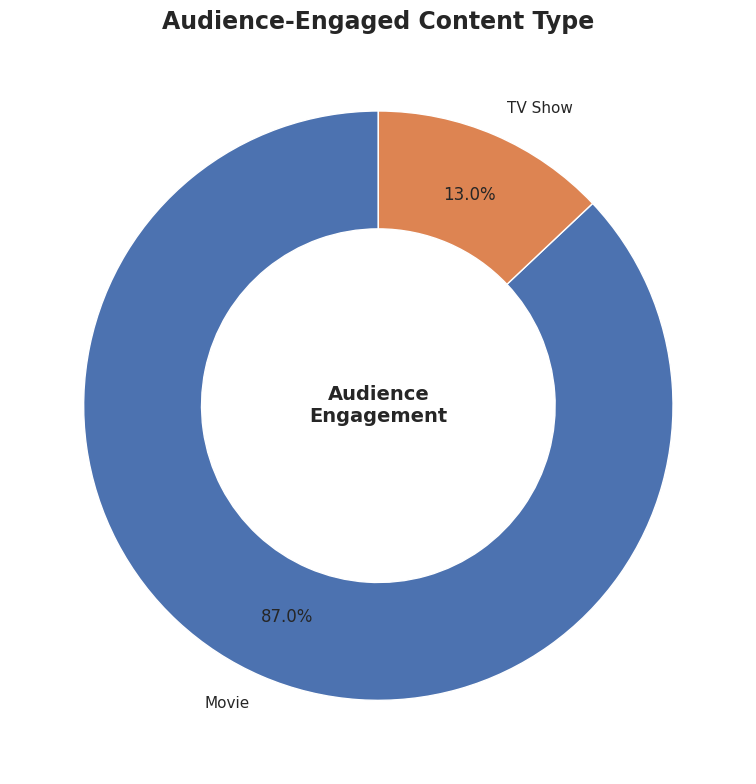


Most audience-engaged content type: Movie


,content_type,Total Viewer Votes
0,Movie,11498498
1,TV Show,1712229


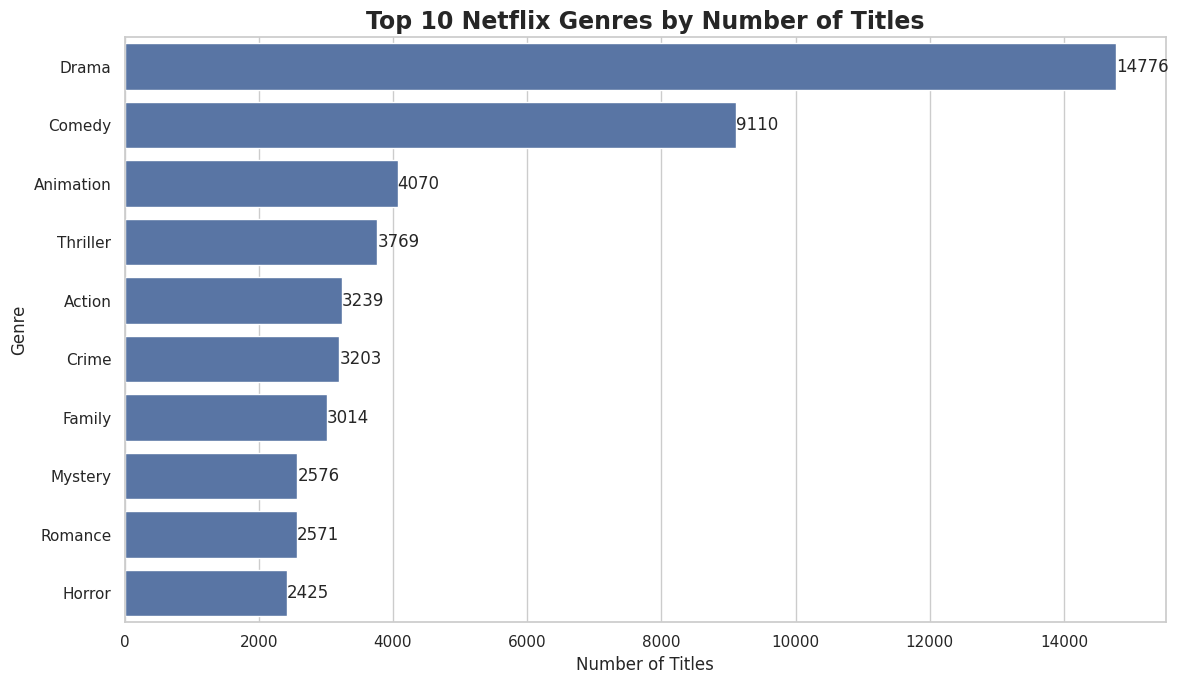

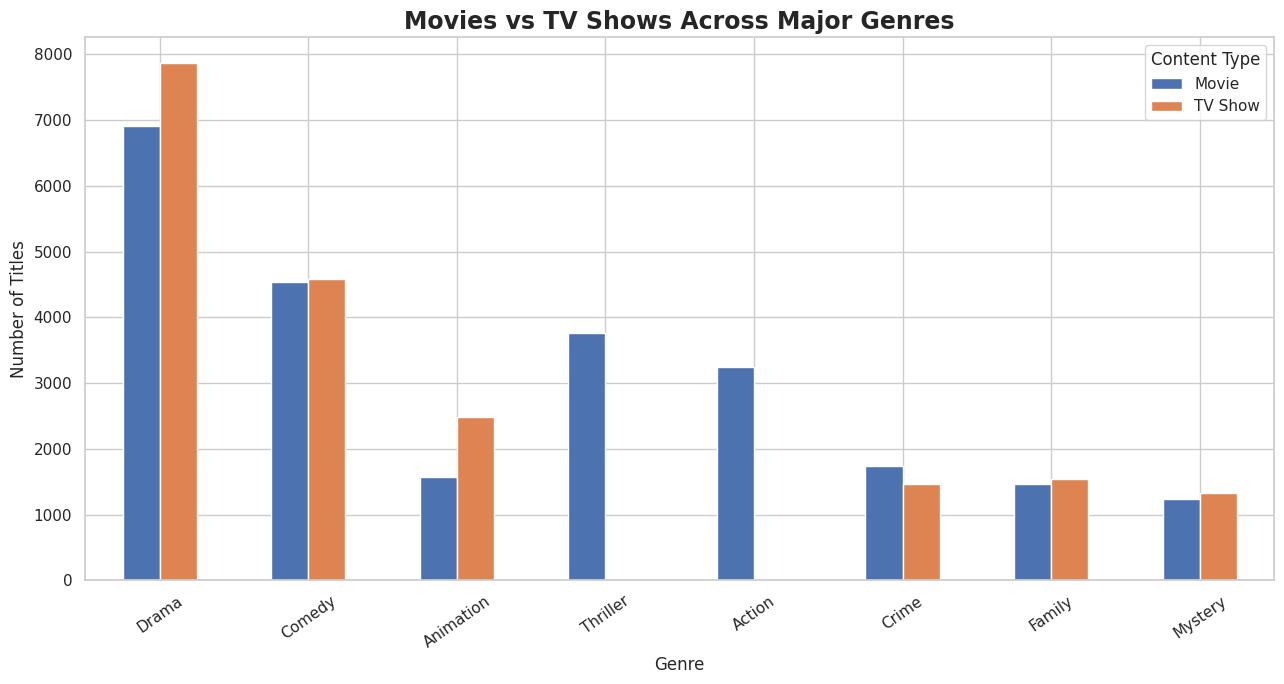

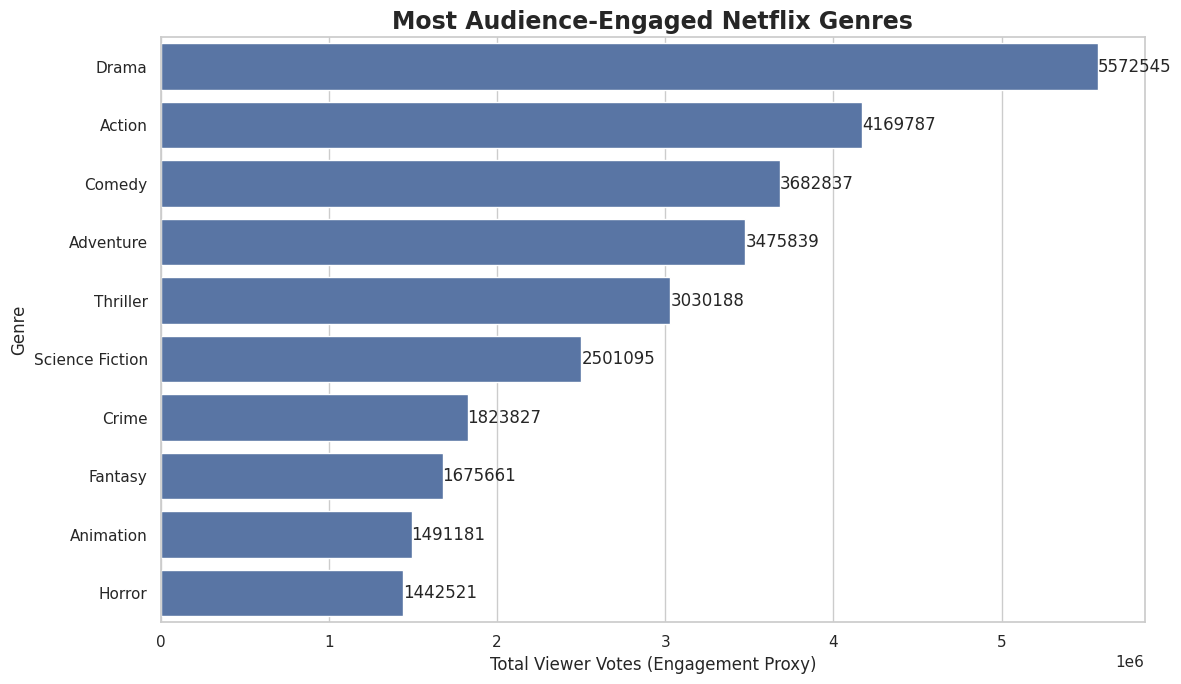


Most audience-engaged genre: Drama


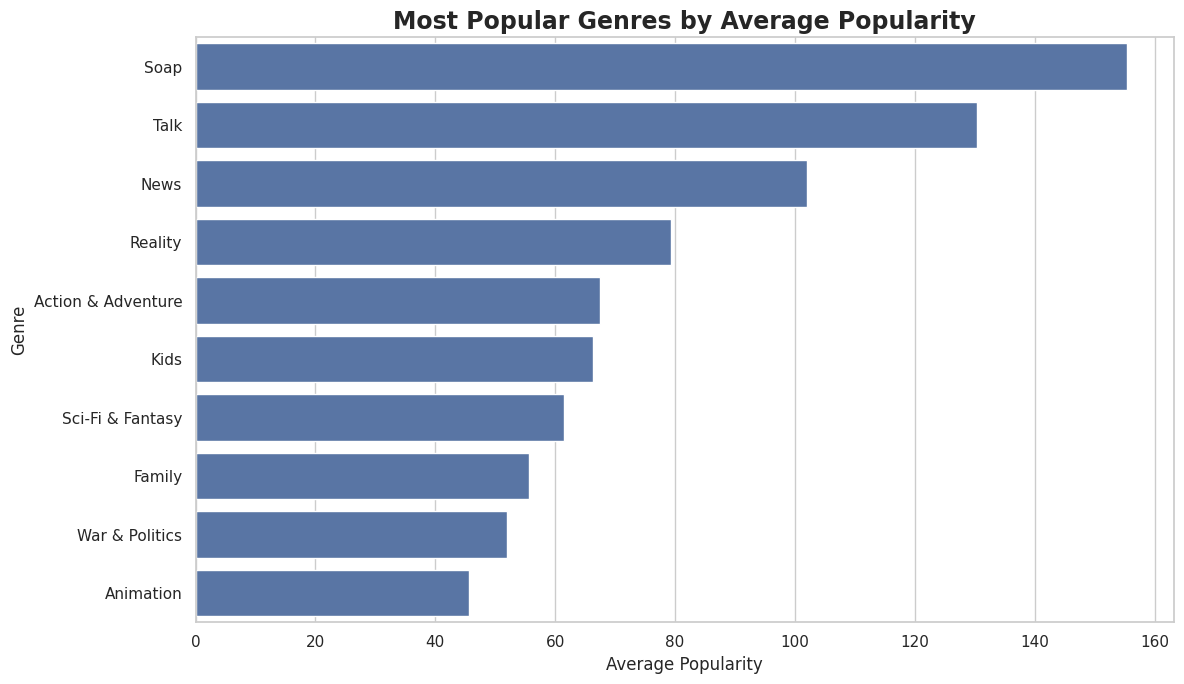

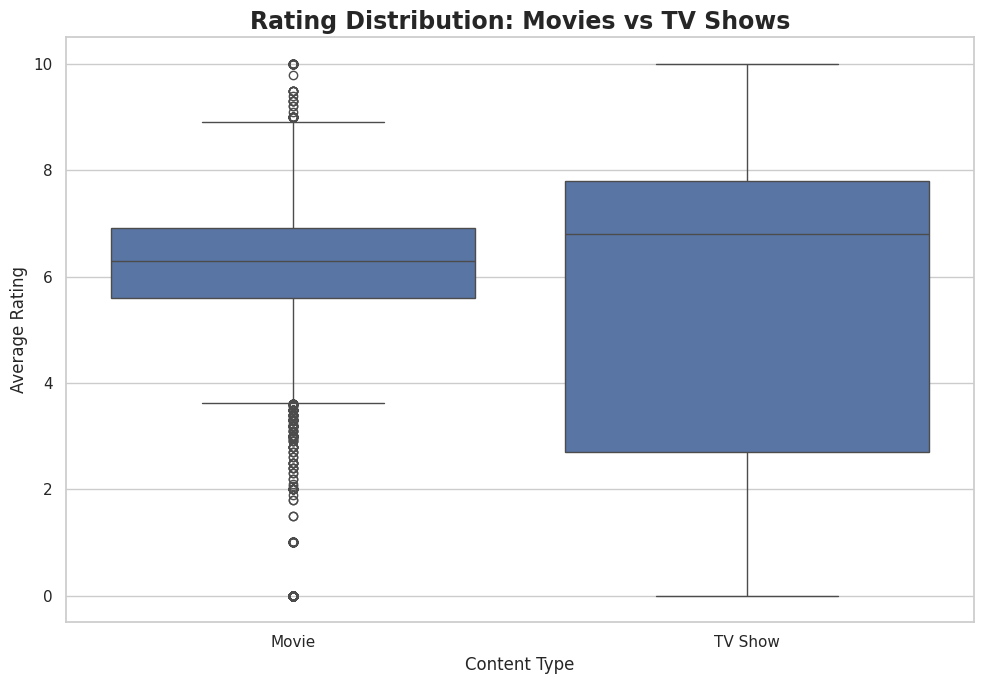

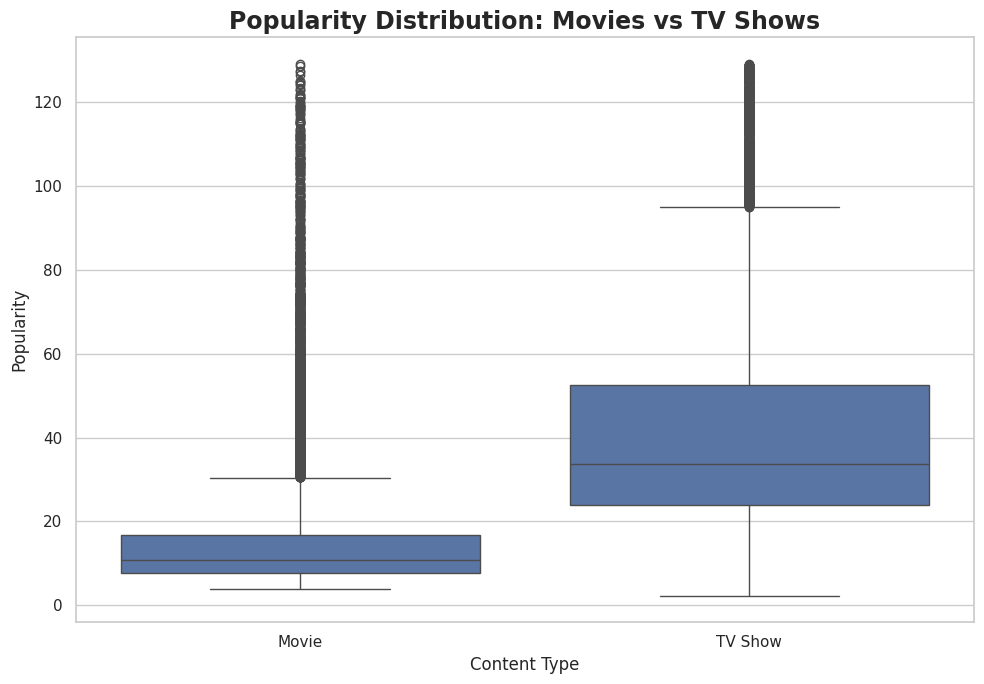

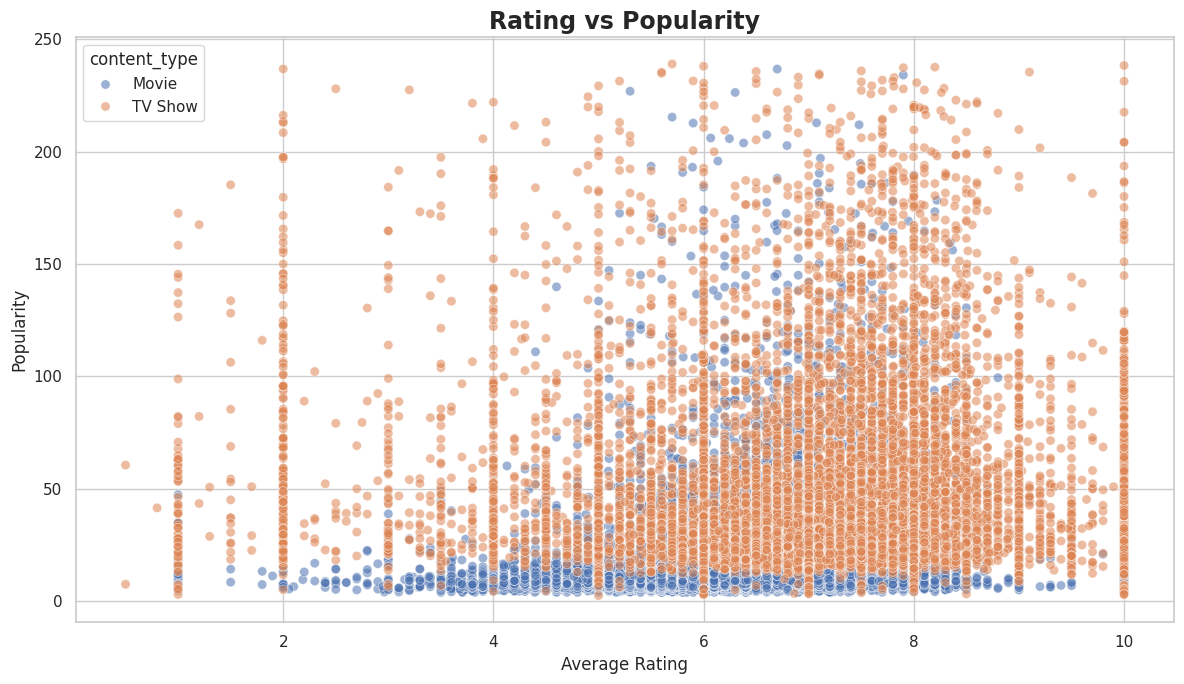

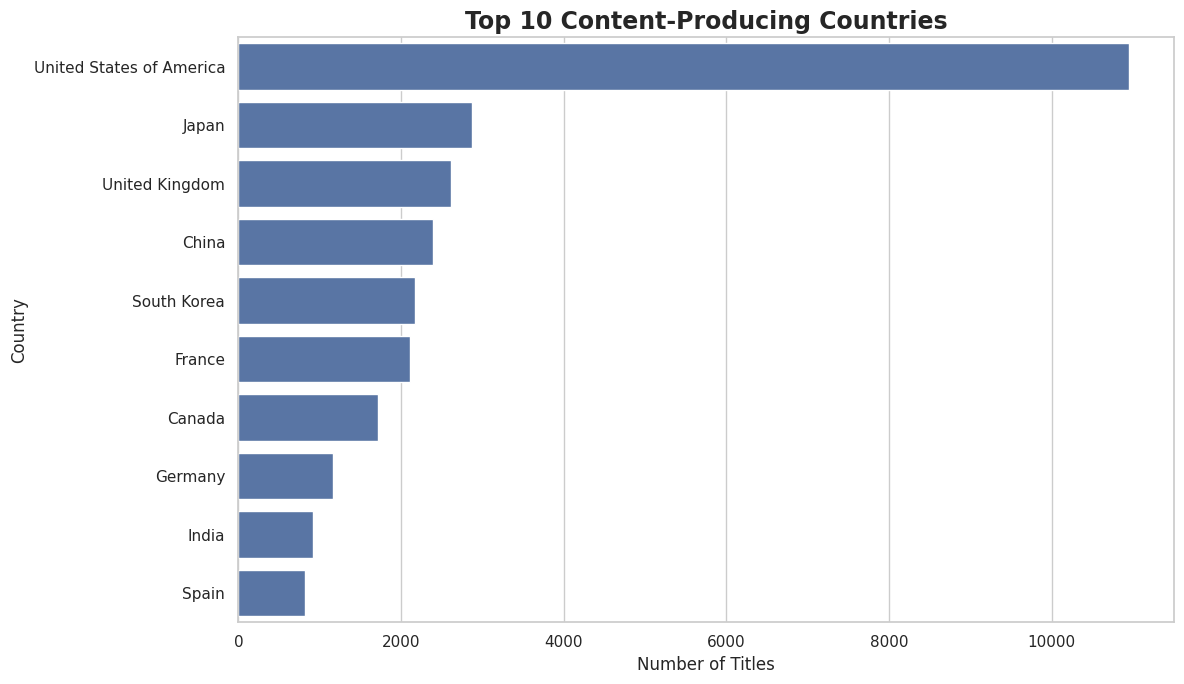

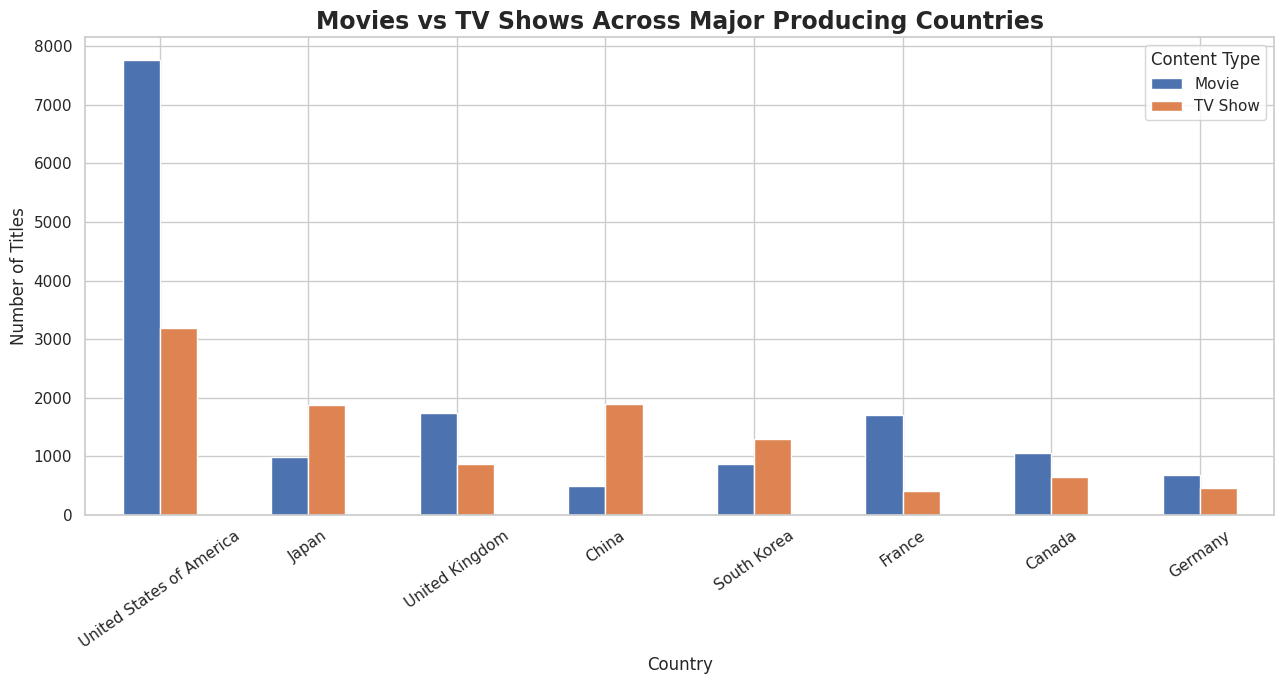


Financial records available: 3540


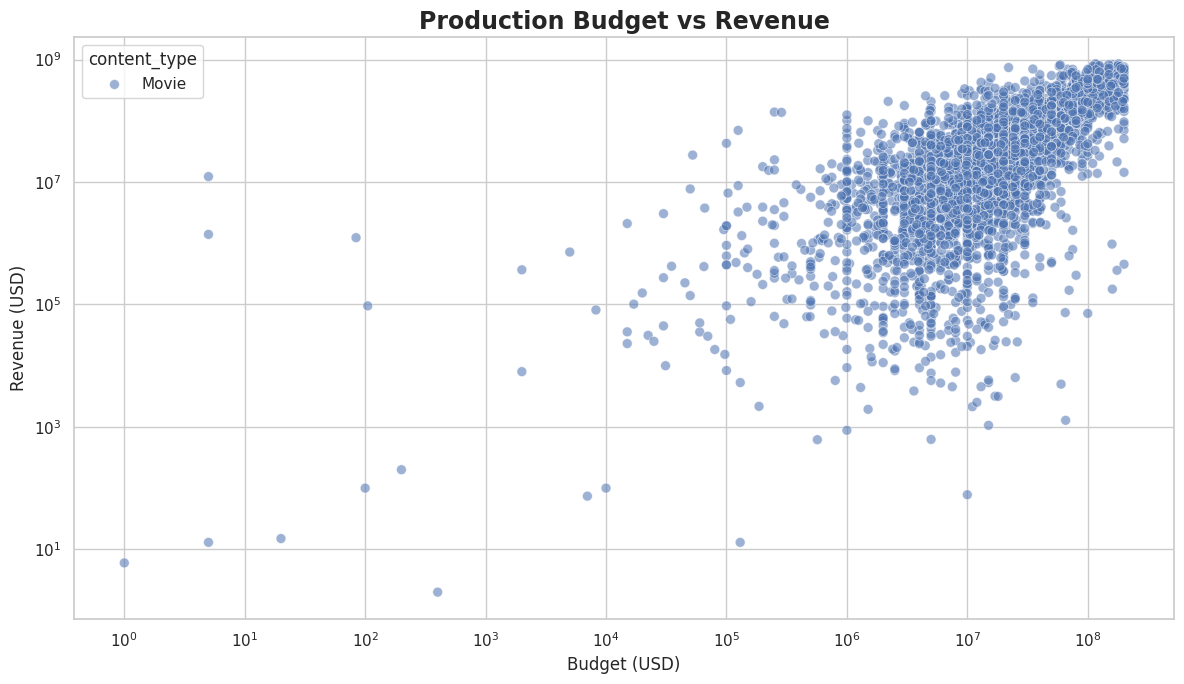

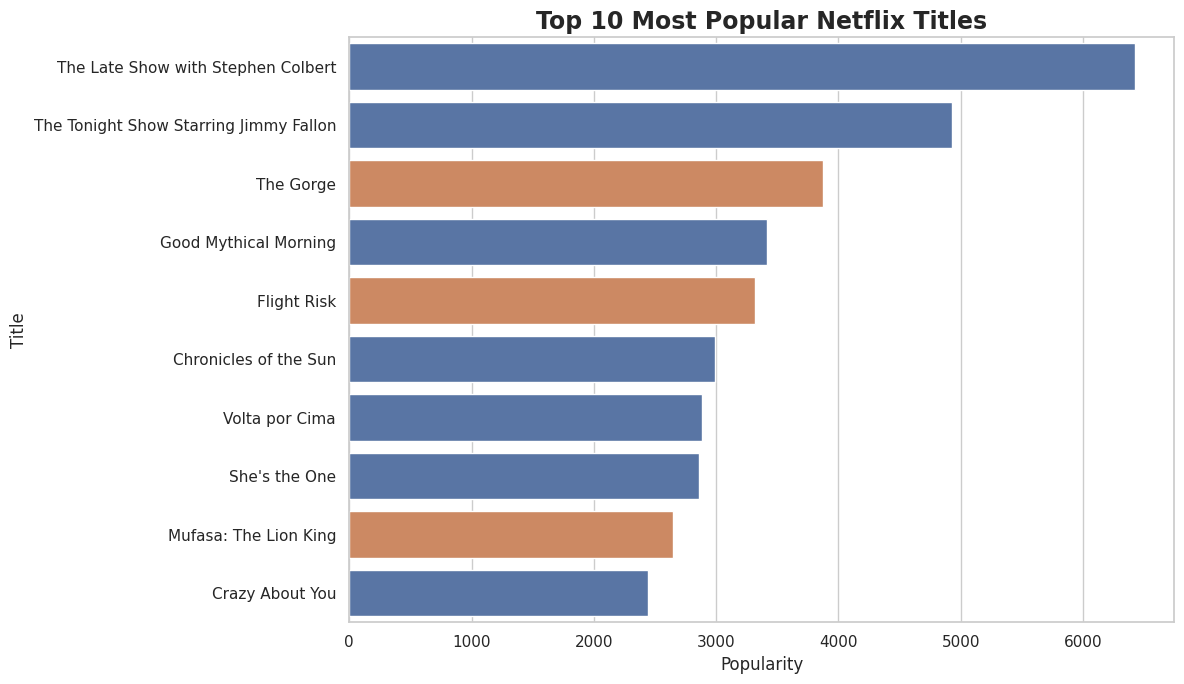

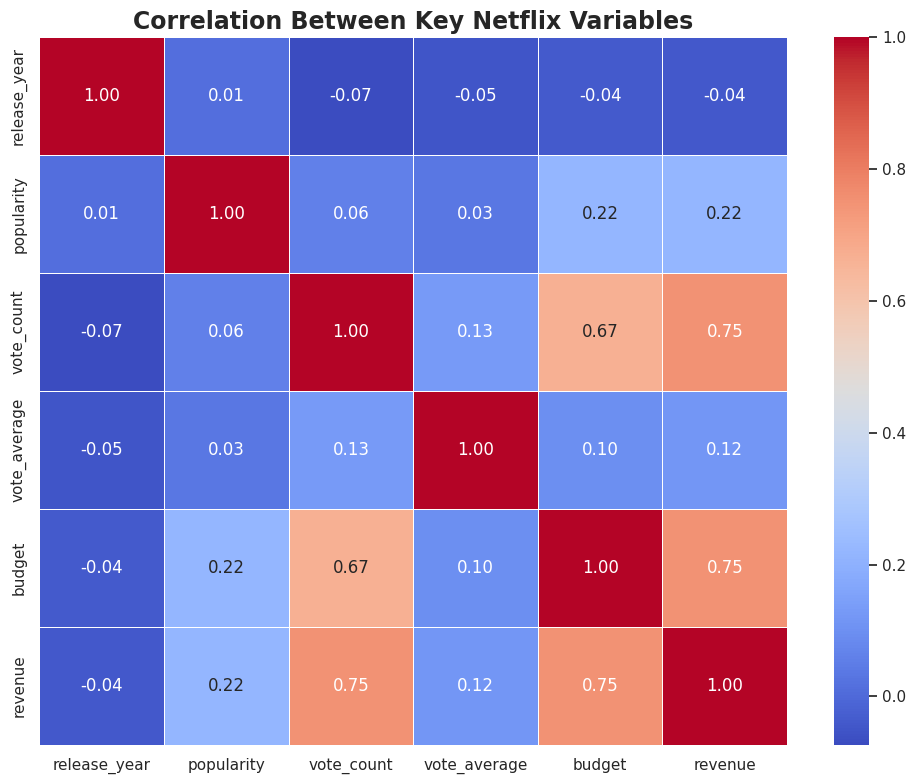


                MOVIE vs TV SHOW SUMMARY


,total_titles,avg_rating,median_rating,avg_popularity,median_popularity,total_votes
content_type,,,,,,
Movie,16000,5.96,6.3,20.38,10.91,11498498
TV Show,16000,5.42,6.8,64.85,36.19,1712229



                     KEY INSIGHTS

1. Most audience-engaged content type: Movie
2. Most common genre: Drama
3. Most audience-engaged genre: Drama
4. Leading content-producing country: United States of America

                DATA-DRIVEN RECOMMENDATIONS

1. Focus on genres showing strong audience engagement
   and high average popularity.

2. Use country-level trends to identify strong regional
   content markets.

3. Consider rating, popularity and vote count together
   instead of relying on a single metric.

4. Analyze budget-revenue relationships before making
   large production investments.

5. Identify highly engaged but underrepresented genres
   as potential content opportunities.


               PROJECT REQUIREMENT CHECKLIST

✓ Two CSV datasets combined
✓ Data cleaning
✓ Data preprocessing
✓ Feature engineering
✓ Audience-engagement donut/ring chart
✓ Genre analysis
✓ Most audience-engaged content type
✓ Most audience-engaged genre
✓ Country analysis
✓ Rating analysis
✓ Pop

In [ ]:
# ================================================================
# NETFLIX MOVIES & TV SHOWS — DATA VISUALIZATION PROJECT
# ================================================================

# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 6)


# ================================================================
# 2. LOAD BOTH CSV FILES
# ================================================================

movies = pd.read_csv(
    "/content/netflix_movies_detailed_up_to_2025.csv"
)

tv_shows = pd.read_csv(
    "/content/netflix_tv_shows_detailed_up_to_2025.csv"
)

print("Movies dataset:", movies.shape)
print("TV Shows dataset:", tv_shows.shape)


# ================================================================
# 3. ADD CONTENT TYPE
# ================================================================

movies["content_type"] = "Movie"
tv_shows["content_type"] = "TV Show"


# ================================================================
# 4. COMBINE BOTH DATASETS
# ================================================================

df = pd.concat(
    [movies, tv_shows],
    ignore_index=True,
    sort=False
)

df = df.drop_duplicates().copy()

print("\nCombined dataset:", df.shape)

display(df.head())


# ================================================================
# 5. DATA CLEANING & PREPROCESSING
# ================================================================

numeric_columns = [
    "release_year",
    "popularity",
    "vote_count",
    "vote_average",
    "budget",
    "revenue"
]

for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )

categorical_columns = [
    "genres",
    "country",
    "language",
    "rating",
    "director"
]

for col in categorical_columns:
    if col in df.columns:
        df[col] = df[col].fillna("Unknown")

if "release_date" in df.columns:
    df["release_date"] = pd.to_datetime(
        df["release_date"],
        errors="coerce"
    )

df["vote_count"] = df["vote_count"].fillna(0)
df["popularity"] = df["popularity"].fillna(0)
df["vote_average"] = df["vote_average"].fillna(0)

# Feature engineering
df["decade"] = (
    (df["release_year"] // 10) * 10
)

df["content_age"] = (
    2026 - df["release_year"]
)


# ================================================================
# 6. DATASET OVERVIEW
# ================================================================

print("\n" + "=" * 65)
print("                    DATASET OVERVIEW")
print("=" * 65)

print("Total titles:", len(df))

print(
    "Movies:",
    (df["content_type"] == "Movie").sum()
)

print(
    "TV Shows:",
    (df["content_type"] == "TV Show").sum()
)

print("\nTop missing-value columns:")

display(
    df.isnull()
      .sum()
      .sort_values(ascending=False)
      .head(15)
)


# ================================================================
# 7. MOST AUDIENCE-ENGAGED CONTENT TYPE
# ================================================================
# Actual Netflix watch-time data is not available in this dataset.
# vote_count is therefore used as an audience-engagement proxy.

content_engagement = (
    df.groupby("content_type")["vote_count"]
      .sum()
      .sort_values(ascending=False)
)


# ---------------- DONUT / RING CHART ----------------

plt.figure(figsize=(8, 8))

plt.pie(
    content_engagement.values,
    labels=content_engagement.index,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.78,
    wedgeprops={
        "width": 0.40,
        "edgecolor": "white"
    }
)

plt.text(
    0,
    0,
    "Audience\nEngagement",
    ha="center",
    va="center",
    fontsize=14,
    fontweight="bold"
)

plt.title(
    "Audience-Engaged Content Type",
    fontsize=17,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

print(
    "\nMost audience-engaged content type:",
    content_engagement.idxmax()
)

display(
    content_engagement.reset_index(
        name="Total Viewer Votes"
    )
)


# ================================================================
# 8. PREPARE GENRE DATA
# ================================================================

genre_df = df[
    [
        "title",
        "content_type",
        "genres",
        "vote_count",
        "popularity",
        "vote_average"
    ]
].copy()

genre_df = genre_df.dropna(
    subset=["genres"]
)

genre_df["genre"] = (
    genre_df["genres"]
    .str.split(r",\s*")
)

genre_df = genre_df.explode(
    "genre"
)

genre_df["genre"] = (
    genre_df["genre"]
    .str.strip()
)

genre_df = genre_df[
    (genre_df["genre"] != "") &
    (genre_df["genre"] != "Unknown")
]


# ================================================================
# 9. TOP 10 GENRES BY NUMBER OF TITLES
# ================================================================

top_genres = (
    genre_df["genre"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title(
    "Top 10 Netflix Genres by Number of Titles",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Number of Titles")
plt.ylabel("Genre")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%d"
    )

plt.tight_layout()
plt.show()


# ================================================================
# 10. MOVIES vs TV SHOWS ACROSS MAJOR GENRES
# ================================================================

genre_type = pd.crosstab(
    genre_df["genre"],
    genre_df["content_type"]
)

top_8_genres = (
    genre_df["genre"]
    .value_counts()
    .head(8)
    .index
)

genre_type = genre_type.loc[
    top_8_genres
]

genre_type.plot(
    kind="bar",
    figsize=(13, 7)
)

plt.title(
    "Movies vs TV Shows Across Major Genres",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Genre")
plt.ylabel("Number of Titles")

plt.xticks(rotation=35)
plt.legend(title="Content Type")

plt.tight_layout()
plt.show()


# ================================================================
# 11. MOST AUDIENCE-ENGAGED GENRES
# ================================================================

genre_engagement = (
    genre_df
    .groupby("genre")["vote_count"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    x=genre_engagement.values,
    y=genre_engagement.index
)

plt.title(
    "Most Audience-Engaged Netflix Genres",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel(
    "Total Viewer Votes (Engagement Proxy)"
)

plt.ylabel("Genre")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f"
    )

plt.tight_layout()
plt.show()

print(
    "\nMost audience-engaged genre:",
    genre_engagement.idxmax()
)


# ================================================================
# 12. AVERAGE POPULARITY BY GENRE
# ================================================================

genre_popularity = (
    genre_df
    .groupby("genre")
    .agg(
        avg_popularity=("popularity", "mean"),
        title_count=("title", "count")
    )
    .query("title_count >= 100")
    .sort_values(
        "avg_popularity",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=genre_popularity,
    x="avg_popularity",
    y=genre_popularity.index
)

plt.title(
    "Most Popular Genres by Average Popularity",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Average Popularity")
plt.ylabel("Genre")

plt.tight_layout()
plt.show()


# ================================================================
# 13. RATING DISTRIBUTION — MOVIES vs TV SHOWS
# ================================================================

rating_df = df[
    df["vote_average"].between(0, 10)
]

plt.figure(figsize=(10, 7))

sns.boxplot(
    data=rating_df,
    x="content_type",
    y="vote_average"
)

plt.title(
    "Rating Distribution: Movies vs TV Shows",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Content Type")
plt.ylabel("Average Rating")

plt.tight_layout()
plt.show()


# ================================================================
# 14. POPULARITY DISTRIBUTION — MOVIES vs TV SHOWS
# ================================================================

popularity_df = df[
    df["popularity"] > 0
].copy()

upper_popularity = (
    popularity_df["popularity"]
    .quantile(0.95)
)

popularity_plot = popularity_df[
    popularity_df["popularity"] <= upper_popularity
]

plt.figure(figsize=(10, 7))

sns.boxplot(
    data=popularity_plot,
    x="content_type",
    y="popularity"
)

plt.title(
    "Popularity Distribution: Movies vs TV Shows",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Content Type")
plt.ylabel("Popularity")

plt.tight_layout()
plt.show()


# ================================================================
# 15. RATING vs POPULARITY
# ================================================================

scatter_df = df[
    (df["vote_average"] > 0) &
    (df["popularity"] > 0)
].copy()

upper_limit = (
    scatter_df["popularity"]
    .quantile(0.98)
)

scatter_df = scatter_df[
    scatter_df["popularity"] <= upper_limit
]

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=scatter_df,
    x="vote_average",
    y="popularity",
    hue="content_type",
    alpha=0.55,
    s=45
)

plt.title(
    "Rating vs Popularity",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Average Rating")
plt.ylabel("Popularity")

plt.tight_layout()
plt.show()


# ================================================================
# 16. PREPARE COUNTRY DATA
# ================================================================

country_df = df[
    [
        "title",
        "content_type",
        "country"
    ]
].copy()

country_df = country_df.dropna(
    subset=["country"]
)

country_df["country"] = (
    country_df["country"]
    .str.split(r",\s*")
)

country_df = country_df.explode(
    "country"
)

country_df["country"] = (
    country_df["country"]
    .str.strip()
)

country_df = country_df[
    (country_df["country"] != "") &
    (country_df["country"] != "Unknown")
]


# ================================================================
# 17. TOP 10 CONTENT-PRODUCING COUNTRIES
# ================================================================

top_countries = (
    country_df["country"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)

plt.title(
    "Top 10 Content-Producing Countries",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.tight_layout()
plt.show()


# ================================================================
# 18. MOVIES vs TV SHOWS — COUNTRY COMPARISON
# ================================================================

country_type = pd.crosstab(
    country_df["country"],
    country_df["content_type"]
)

top_country_names = (
    country_df["country"]
    .value_counts()
    .head(8)
    .index
)

country_type.loc[
    top_country_names
].plot(
    kind="bar",
    figsize=(13, 7)
)

plt.title(
    "Movies vs TV Shows Across Major Producing Countries",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Country")
plt.ylabel("Number of Titles")

plt.xticks(rotation=35)
plt.legend(title="Content Type")

plt.tight_layout()
plt.show()


# ================================================================
# 19. BUDGET vs REVENUE
# ================================================================

financial_df = df[
    (df["budget"] > 0) &
    (df["revenue"] > 0)
].copy()

print(
    "\nFinancial records available:",
    len(financial_df)
)

if len(financial_df) > 0:

    budget_limit = (
        financial_df["budget"]
        .quantile(0.98)
    )

    revenue_limit = (
        financial_df["revenue"]
        .quantile(0.98)
    )

    financial_plot = financial_df[
        (financial_df["budget"] <= budget_limit) &
        (financial_df["revenue"] <= revenue_limit)
    ]

    plt.figure(figsize=(12, 7))

    sns.scatterplot(
        data=financial_plot,
        x="budget",
        y="revenue",
        hue="content_type",
        alpha=0.55,
        s=50
    )

    plt.title(
        "Production Budget vs Revenue",
        fontsize=17,
        fontweight="bold"
    )

    plt.xlabel("Budget (USD)")
    plt.ylabel("Revenue (USD)")

    plt.xscale("log")
    plt.yscale("log")

    plt.tight_layout()
    plt.show()


# ================================================================
# 20. TOP 10 MOST POPULAR TITLES
# ================================================================

top_titles = (
    df[
        df["popularity"] > 0
    ]
    .sort_values(
        "popularity",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_titles,
    x="popularity",
    y="title",
    hue="content_type",
    legend=False
)

plt.title(
    "Top 10 Most Popular Netflix Titles",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Popularity")
plt.ylabel("Title")

plt.tight_layout()
plt.show()


# ================================================================
# 21. CORRELATION HEATMAP
# ================================================================

correlation_columns = [
    "release_year",
    "popularity",
    "vote_count",
    "vote_average",
    "budget",
    "revenue"
]

correlation_columns = [
    col for col in correlation_columns
    if col in df.columns
]

correlation = df[
    correlation_columns
].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title(
    "Correlation Between Key Netflix Variables",
    fontsize=17,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


# ================================================================
# 22. MOVIE vs TV SHOW SUMMARY
# ================================================================

summary = (
    df.groupby("content_type")
      .agg(
          total_titles=("title", "count"),
          avg_rating=("vote_average", "mean"),
          median_rating=("vote_average", "median"),
          avg_popularity=("popularity", "mean"),
          median_popularity=("popularity", "median"),
          total_votes=("vote_count", "sum")
      )
      .round(2)
)

print("\n" + "=" * 70)
print("                MOVIE vs TV SHOW SUMMARY")
print("=" * 70)

display(summary)


# ================================================================
# 23. KEY INSIGHTS
# ================================================================

print("\n" + "=" * 70)
print("                     KEY INSIGHTS")
print("=" * 70)

print(
    "\n1. Most audience-engaged content type:",
    content_engagement.idxmax()
)

print(
    "2. Most common genre:",
    top_genres.idxmax()
)

print(
    "3. Most audience-engaged genre:",
    genre_engagement.idxmax()
)

print(
    "4. Leading content-producing country:",
    top_countries.idxmax()
)


# ================================================================
# 24. DATA-DRIVEN RECOMMENDATIONS
# ================================================================

print("\n" + "=" * 70)
print("                DATA-DRIVEN RECOMMENDATIONS")
print("=" * 70)

print("""
1. Focus on genres showing strong audience engagement
   and high average popularity.

2. Use country-level trends to identify strong regional
   content markets.

3. Consider rating, popularity and vote count together
   instead of relying on a single metric.

4. Analyze budget-revenue relationships before making
   large production investments.

5. Identify highly engaged but underrepresented genres
   as potential content opportunities.
""")


# ================================================================
# 25. PROJECT REQUIREMENT CHECKLIST
# ================================================================

print("\n" + "=" * 70)
print("               PROJECT REQUIREMENT CHECKLIST")
print("=" * 70)

print("""
✓ Two CSV datasets combined
✓ Data cleaning
✓ Data preprocessing
✓ Feature engineering
✓ Audience-engagement donut/ring chart
✓ Genre analysis
✓ Most audience-engaged content type
✓ Most audience-engaged genre
✓ Country analysis
✓ Rating analysis
✓ Popularity analysis
✓ Budget vs revenue analysis
✓ Scatter plots
✓ Box plots
✓ Bar charts
✓ Correlation heatmap
✓ Data-driven insights
✓ Data storytelling
✓ Business recommendations
""")

print("\n🎬 NETFLIX DATA VISUALIZATION PROJECT COMPLETED!")
